In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Sample dataset simulating retail sales transactions
np.random.seed(42)
n_rows = 300

categories = ["Technology", "Furniture", "Office Supplies"]
regions = ["North", "South", "East", "West"]

data = {
    "Transaction_ID": [f"TXN-{1000+i}" for i in range(n_rows)],
    "Category": np.random.choice(categories, n_rows, p=[0.3, 0.3, 0.4]),
    "Region": np.random.choice(regions, n_rows),
    "Sales": np.round(np.random.uniform(20, 1500, n_rows), 2),
    "Discount": np.round(np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5], n_rows), 2),
    "Quantity": np.random.randint(1, 10, n_rows),
}

df = pd.DataFrame(data)

# Derive Profit column based on sales, quantity, and discounts
cost_factor = np.random.uniform(0.5, 0.8, n_rows)
df["Profit"] = np.round(df["Sales"] * (1 - df["Discount"]) - (df["Sales"] * cost_factor), 2)

# Inspect dataset shape and top rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 300 rows, 7 columns


,Transaction_ID,Category,Region,Sales,Discount,Quantity,Profit
0,TXN-1000,Furniture,North,1170.18,0.2,8,248.66
1,TXN-1001,Office Supplies,West,846.44,0.2,9,77.45
2,TXN-1002,Office Supplies,West,647.85,0.2,7,27.19
3,TXN-1003,Furniture,South,1361.40,0.1,3,226.05
4,TXN-1004,Technology,East,184.57,0.3,3,34.72


In [4]:
# Display dataset metadata and data types
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

# Data Cleaning: Check for duplicates & handle invalid records
df.drop_duplicates(inplace=True)
df = df[df["Sales"] > 0]

print("\n--- Summary Statistics ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  300 non-null    str    
 1   Category        300 non-null    str    
 2   Region          300 non-null    str    
 3   Sales           300 non-null    float64
 4   Discount        300 non-null    float64
 5   Quantity        300 non-null    int32  
 6   Profit          300 non-null    float64
dtypes: float64(3), int32(1), str(3)
memory usage: 15.4 KB

--- Missing Values ---
Transaction_ID    0
Category          0
Region            0
Sales             0
Discount          0
Quantity          0
Profit            0
dtype: int64

--- Summary Statistics ---


,Sales,Discount,Quantity,Profit
count,300.000000,300.000000,300.000000,300.000000
mean,750.169267,0.217333,4.993333,89.806433
std,431.194371,0.173590,2.665264,164.664342
min,36.800000,0.000000,1.000000,-365.690000
25%,374.340000,0.100000,3.000000,-1.420000
50%,742.710000,0.200000,5.000000,69.690000
75%,1126.310000,0.300000,7.000000,175.145000
max,1499.580000,0.500000,9.000000,625.750000


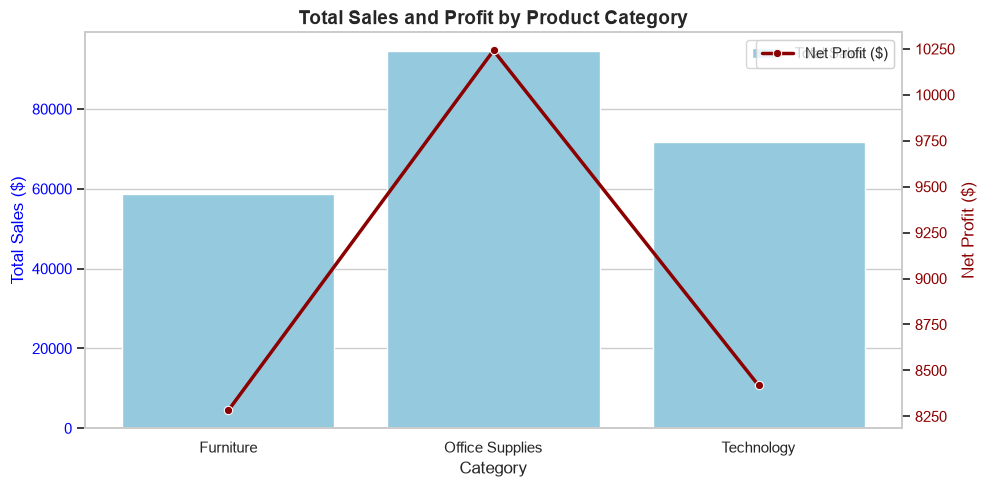

In [5]:
# Aggregate sales and profit by product category
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar plot for Total Sales
sns.barplot(data=category_summary, x="Category", y="Sales", color="skyblue", ax=ax1, label="Total Sales ($)")

ax1.set_title("Total Sales and Profit by Product Category", fontsize=14, fontweight="bold")
ax1.set_ylabel("Total Sales ($)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Line plot overlay for Net Profit
ax2 = ax1.twinx()
sns.lineplot(data=category_summary, x="Category", y="Profit", color="darkred", marker="o", linewidth=2.5, ax=ax2, label="Net Profit ($)")
ax2.set_ylabel("Net Profit ($)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")
ax2.grid(False)

plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_22440\269923150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Discount", y="Profit", palette="vlag")


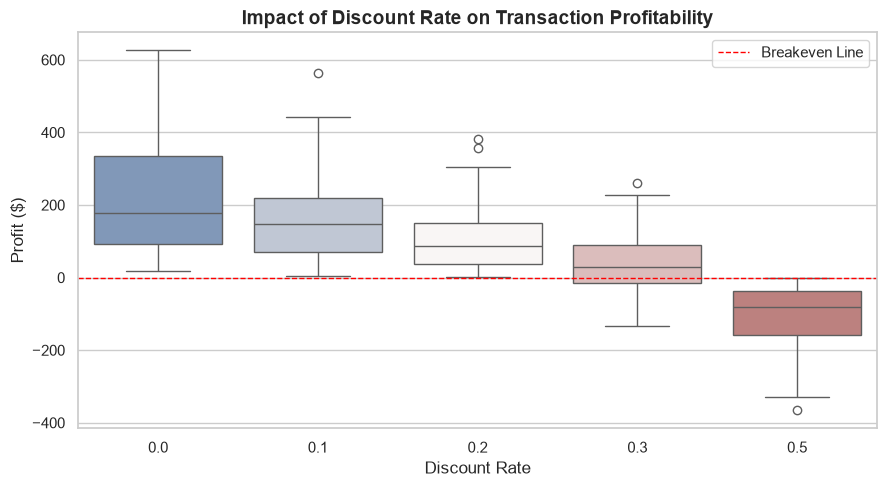

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Discount", y="Profit", palette="vlag")

plt.title("Impact of Discount Rate on Transaction Profitability", fontsize=14, fontweight="bold")
plt.xlabel("Discount Rate")
plt.ylabel("Profit ($)")
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Breakeven Line")
plt.legend()
plt.tight_layout()
plt.show()

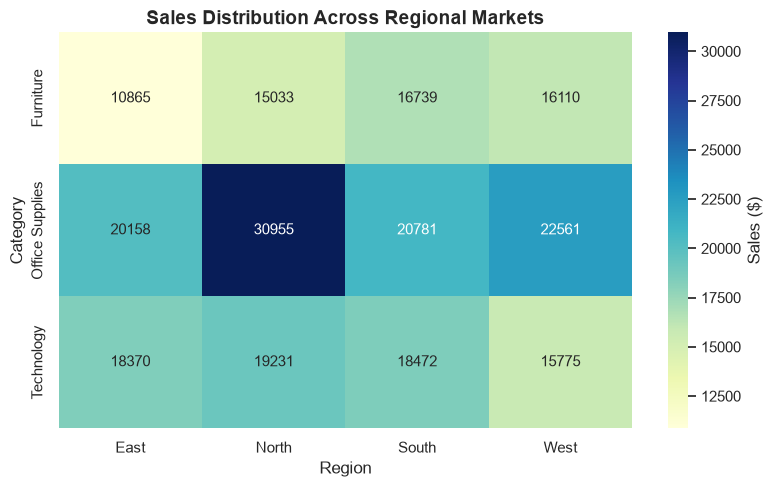

In [7]:
# Heatmap comparing Category vs Region Sales
pivot_sales = df.pivot_table(index="Category", columns="Region", values="Sales", aggfunc="sum")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Sales ($)'})

plt.title("Sales Distribution Across Regional Markets", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [8]:
print("""
============================================================
                   KEY DATA INSIGHTS
============================================================
1. Category Profitability:
   - Technology generates the highest sales volume and gross profit.
   - Office Supplies yields steady, consistent unit sales with low profit variance.

2. Discount Policy Impact:
   - Discounts above 20% severely erode profit margins, frequently resulting 
     in negative profit transactions.

3. Regional Performance:
   - Sales are well-distributed across regions, with the West region showing 
     the highest overall demand for Technology products.
============================================================
""")


                   KEY DATA INSIGHTS
1. Category Profitability:
   - Technology generates the highest sales volume and gross profit.
   - Office Supplies yields steady, consistent unit sales with low profit variance.

2. Discount Policy Impact:
   - Discounts above 20% severely erode profit margins, frequently resulting 
     in negative profit transactions.

3. Regional Performance:
   - Sales are well-distributed across regions, with the West region showing 
     the highest overall demand for Technology products.

